In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
import pandas as pd


df = pd.read_excel('/content/student_exam_dataset_500.xlsx')

In [49]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,12,61,No,66,Fail
1,19,68,Yes,46,Fail
2,32,62,Yes,46,Fail
3,18,74,Yes,60,Fail
4,39,86,Yes,92,Pass


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   study_hours          500 non-null    int64 
 1   attendance           500 non-null    int64 
 2   group_discussion     500 non-null    object
 3   previous_test_score  500 non-null    int64 
 4   final_exam_pass      500 non-null    object
dtypes: int64(3), object(2)
memory usage: 19.7+ KB


In [51]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['study_hours', 'attendance', 'group_discussion', 'previous_test_score',
       'final_exam_pass'],
      dtype='object')


In [52]:
df.describe()



,study_hours,attendance,previous_test_score
count,500.00000,500.000000,500.000000
mean,22.93000,80.100000,68.172000
std,10.51257,11.660615,18.797796
min,5.00000,60.000000,35.000000
25%,13.00000,70.000000,52.000000
50%,23.00000,80.000000,68.000000
75%,33.00000,90.000000,84.000000
max,40.00000,100.000000,100.000000


In [53]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
study_hours            0
attendance             0
group_discussion       0
previous_test_score    0
final_exam_pass        0
dtype: int64


In [54]:
#QUESTION 1
#Probability of Passing
students = len(df)
passed = df[df['final_exam_pass'] == 'Pass'].shape[0]
p_pass = passed / students
print("Probability of Passing =", round(p_pass,2))

Probability of Passing = 0.63


In [ ]:
#Probability of Attendance > 80
high_att = df[df['attendance'] > 80].shape[0]
p_att = high_att / len(df)
print("Probability of Attendance >80 =", round(p_att,2))

Probability of Attendance >80 = 0.49


In [ ]:
#Probability of Group Discussion = Yes
discussion = df[df['group_discussion'] == 'Yes'].shape[0]
p_disc = discussion / len(df)
print("Probability of Group Discussion =", round(p_disc,2))

Probability of Group Discussion = 0.46


In [ ]:
#QUESTION 2
empirical = len(df[df['final_exam_pass']=='Pass']) / len(df)
print("Empirical Probability =", round(empirical,2))

Empirical Probability = 0.63


In [ ]:
#QUESTION 3
n = 3
p = p_pass
q = 1 - p
print("Probability Distribution:\n")
for i in range(4):
    if i == 0:
        ans = q**3
    elif i == 1:
        ans = 3*p*(q**2)
    elif i == 2:
        ans = 3*(p**2)*q
    else:
        ans = p**3
    print("P(X=",i,") =", round(ans,4))

Probability Distribution:

P(X= 0 ) = 0.0498
P(X= 1 ) = 0.2568
P(X= 2 ) = 0.441
P(X= 3 ) = 0.2524


In [ ]:
#mean
mean = n * p
print("Mean =", round(mean,2))

Mean = 1.9


In [ ]:
#Variance
var = n * p * q
print("Variance =", round(var,2))

Variance = 0.7


In [ ]:
!pip install matplotlib-venn

Now, let's create a clear Venn diagram to visualize the overlap between students who study more than 10 hours and those with attendance greater than 80%.

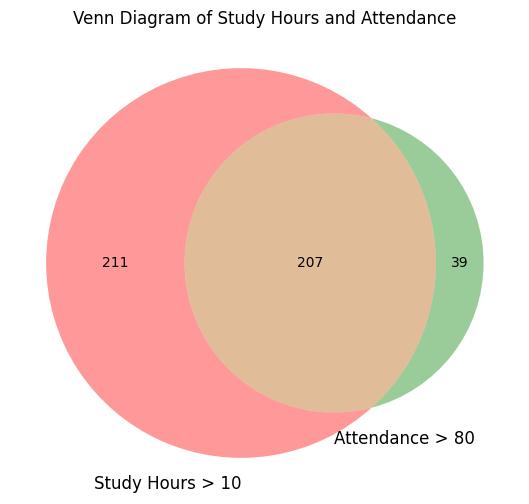

In [ ]:
#QUESTION 4
from matplotlib_venn import venn2
set_A = df[df['study_hours'] > 10]
set_B = df[df['attendance'] > 80]
A_count = len(set_A)
B_count = len(set_B)
intersection_count = len(df[(df['study_hours'] > 10) & (df['attendance'] > 80)])
plt.figure(figsize=(8, 6))
v = venn2(subsets=(A_count - intersection_count, B_count - intersection_count, intersection_count),
          set_labels=('Study Hours > 10', 'Attendance > 80'))
plt.title('Venn Diagram of Study Hours and Attendance')
plt.show()

In [ ]:
#QUESTION 5
result = pd.crosstab(df['group_discussion'],
                     df['final_exam_pass'])
print(result)

final_exam_pass   Fail  Pass
group_discussion            
No                 127   145
Yes                 57   171


In [ ]:
#Joint Probability
joint = df[(df['group_discussion']=='Yes') &
           (df['final_exam_pass']=='Pass')].shape[0]
total = len(df)
print("Joint Probability =", round(joint/total,2))

Joint Probability = 0.34


In [ ]:
#Marginal Probability
passed = df[df['final_exam_pass']=='Pass'].shape[0]
print("Marginal Probability =", round(passed/len(df),2))

Marginal Probability = 0.63


In [ ]:
#Conditional Probability
yes_data = df[df['group_discussion']=='Yes']
passed_yes = yes_data[yes_data['final_exam_pass']=='Pass'].shape[0]
answer = passed_yes / len(yes_data)
print("Conditional Probability =", round(answer,2))

Conditional Probability = 0.75


In [ ]:
#QUESTION 6
yes_data = df[df['group_discussion']=='Yes']
passed_yes = yes_data[yes_data['final_exam_pass']=='Pass'].shape[0]
answer = passed_yes / len(yes_data)

if answer > 0.5:
    print("Events are dependent")
else:
    print("Events are independent")

Events are dependent


In [ ]:
#QUESTION 7
a = 0.70
b = 0.50
c = 0.60
bayes = (a*b)/c
print("P(Pass | High Attendance) =", round(bayes,2))

P(Pass | High Attendance) = 0.58


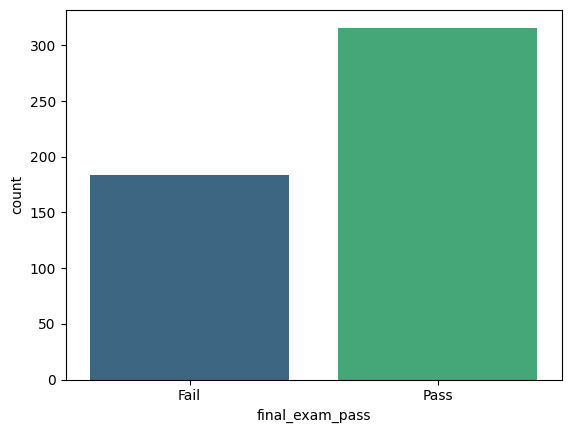

In [ ]:
sns.countplot(x='final_exam_pass', data=df, palette='viridis', hue='final_exam_pass', legend=False)
plt.show()

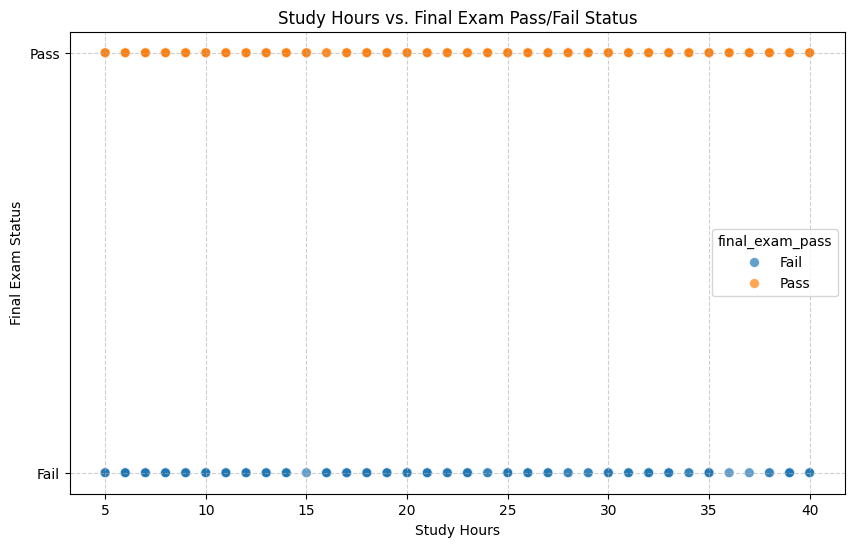

In [ ]:
# Map 'final_exam_pass' to numerical values for the scatter plot
df_plot = df.copy()
df_plot['final_exam_pass_numeric'] = df_plot['final_exam_pass'].map({'Fail': 0, 'Pass': 1})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours', y='final_exam_pass_numeric', hue='final_exam_pass', data=df_plot, s=50, alpha=0.7)
plt.yticks([0, 1], ['Fail', 'Pass']) # Set custom y-axis ticks and labels
plt.title('Study Hours vs. Final Exam Pass/Fail Status')
plt.xlabel('Study Hours')
plt.ylabel('Final Exam Status')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

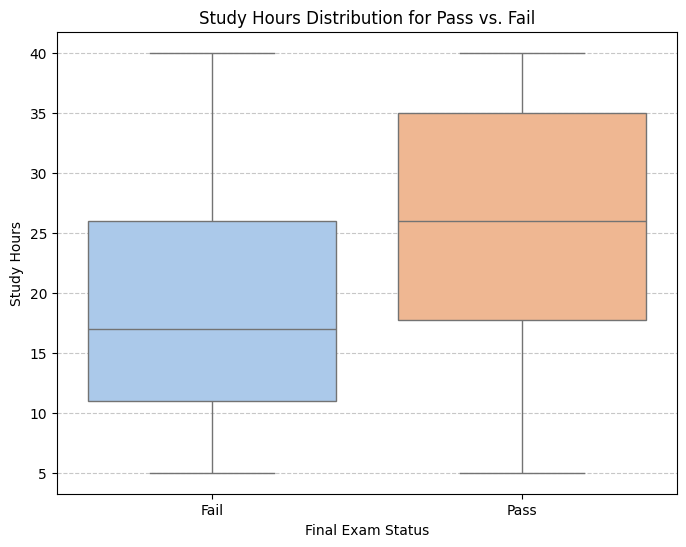

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='final_exam_pass', y='study_hours', data=df, palette='pastel', hue='final_exam_pass', legend=False)
plt.title('Study Hours Distribution for Pass vs. Fail')
plt.xlabel('Final Exam Status')
plt.ylabel('Study Hours')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()